In [38]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor  # Changed to Regressor for predicting views
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV


In [39]:
# TESTING ON 100 rows
df = pd.read_csv('ml_final_project_data/cleaned_data.csv')
df.head()

# Features and label
X = df.drop(columns=['views', 'region'])
y = df['views']

X.head()


,platform,country,category,sound_type,duration_sec,likes,comments,trend_label,genre,publish_dayofweek,publish_period,creator_avg_views,title_length,completion_rate,traffic_source
0,1,Us,Food,licensed,26,1868,257,rising,Travel,Sunday,Evening,86079.6,22,0.777,ForYou
1,1,Us,Fitness,trending,18,8917,1084,seasonal,Music,Sunday,Night,101492.8,17,0.728,ForYou
2,1,Us,Comedy,trending,62,35108,4168,rising,Pets,Friday,Evening,91145.8,20,0.806,ForYou
3,1,Mx,Travel,trending,23,3677,307,declining,Lifestyle,Thursday,Afternoon,85917.1,24,0.678,ForYou
4,1,Mx,Lifestyle,original,41,1373,151,declining,Beauty,Saturday,Night,90734.5,22,0.815,ForYou


In [40]:
# Check data types to identify categorical columns
print("Data types:")
print(df.dtypes)
print("\n" + "="*50)
print("Categorical columns (object type):")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)
print(f"\nTotal categorical columns: {len(categorical_cols)}")

Data types:
platform               int64
country               object
region                object
category              object
sound_type            object
duration_sec           int64
views                  int64
likes                  int64
comments               int64
trend_label           object
genre                 object
publish_dayofweek     object
publish_period        object
creator_avg_views    float64
title_length           int64
completion_rate      float64
traffic_source        object
dtype: object

Categorical columns (object type):
['country', 'region', 'category', 'sound_type', 'trend_label', 'genre', 'publish_dayofweek', 'publish_period', 'traffic_source']

Total categorical columns: 9


In [41]:
# Convert categorical columns to numeric using Label Encoding
from sklearn.preprocessing import LabelEncoder

# Create a copy to avoid modifying original
df_encoded = df.copy()

# Get categorical columns (excluding 'views' which is our target)
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()

# Remove 'views' if it's in the list (it's our target)
if 'views' in categorical_cols:
    categorical_cols.remove('views')

# Apply Label Encoding to each categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded '{col}': {len(le.classes_)} unique categories")

print("\n" + "="*50)
print(f"Total columns encoded: {len(categorical_cols)}")
print("All categorical data converted to numeric!")

# Update X and y with encoded data
X_encoded = df_encoded.drop(columns=['views', 'region'])
y_encoded = df_encoded['views']

print("\n" + "="*50)
print(f"Features shape: {X_encoded.shape}")
print(f"Target shape: {y_encoded.shape}")
print(f"\nAll data is now numeric: {X_encoded.select_dtypes(include=['object']).shape[1] == 0}")
print("Total rows:", X_encoded.shape[0])

X_encoded.head()

Encoded 'country': 3 unique categories
Encoded 'region': 1 unique categories
Encoded 'category': 19 unique categories
Encoded 'sound_type': 3 unique categories
Encoded 'trend_label': 4 unique categories
Encoded 'genre': 14 unique categories
Encoded 'publish_dayofweek': 7 unique categories
Encoded 'publish_period': 4 unique categories
Encoded 'traffic_source': 6 unique categories

Total columns encoded: 9
All categorical data converted to numeric!

Features shape: (4864, 15)
Target shape: (4864,)

All data is now numeric: True
Total rows: 4864


,platform,country,category,sound_type,duration_sec,likes,comments,trend_label,genre,publish_dayofweek,publish_period,creator_avg_views,title_length,completion_rate,traffic_source
0,1,2,9,0,26,1868,257,1,13,3,1,86079.6,22,0.777,2
1,1,2,8,2,18,8917,1084,2,9,3,3,101492.8,17,0.728,2
2,1,2,3,2,62,35108,4168,1,10,0,1,91145.8,20,0.806,2
3,1,1,18,2,23,3677,307,0,8,4,0,85917.1,24,0.678,2
4,1,1,11,1,41,1373,151,0,0,2,3,90734.5,22,0.815,2


In [42]:
# Hyperparameter grid for XGBoost Regressor
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

print("Parameter grid:", param_grid)
print(f"Total combinations: {2 * 2 * 1 * 1 * 1} = 4")

Parameter grid: {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.1], 'subsample': [0.8], 'colsample_bytree': [0.8]}
Total combinations: 4 = 4


In [43]:
# Train XGBoost Regressor with GridSearchCV on all rows
print("Training XGBoost Regressor with GridSearchCV...")

# Use negative MSE as scoring (GridSearchCV maximizes, so negative)
model = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1
)

model.fit(X_encoded, y_encoded)

# Get best parameters and model
best_params = model.best_params_
best_model = model.best_estimator_

# Make predictions
y_pred = best_model.predict(X_encoded)

# Calculate metrics
mse = mean_squared_error(y_encoded, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_encoded, y_pred)
r2 = r2_score(y_encoded, y_pred)

print("\n" + "="*50)
print("XGBoost Regressor Results")
print("="*50)
print("Best Parameters:", best_params)
print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")
print(f"R² Score: {r2:.4f}")
print("="*50)

Training XGBoost Regressor with GridSearchCV...

XGBoost Regressor Results
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
RMSE: 35,401.01
MAE: 20,741.61
R² Score: 0.9229


Top 10 Most Important Features:
              feature  importance
5               likes    0.407898
6            comments    0.130757
0            platform    0.102908
4        duration_sec    0.056751
2            category    0.052181
1             country    0.047757
11  creator_avg_views    0.040184
14     traffic_source    0.034401
10     publish_period    0.031799
12       title_length    0.026507


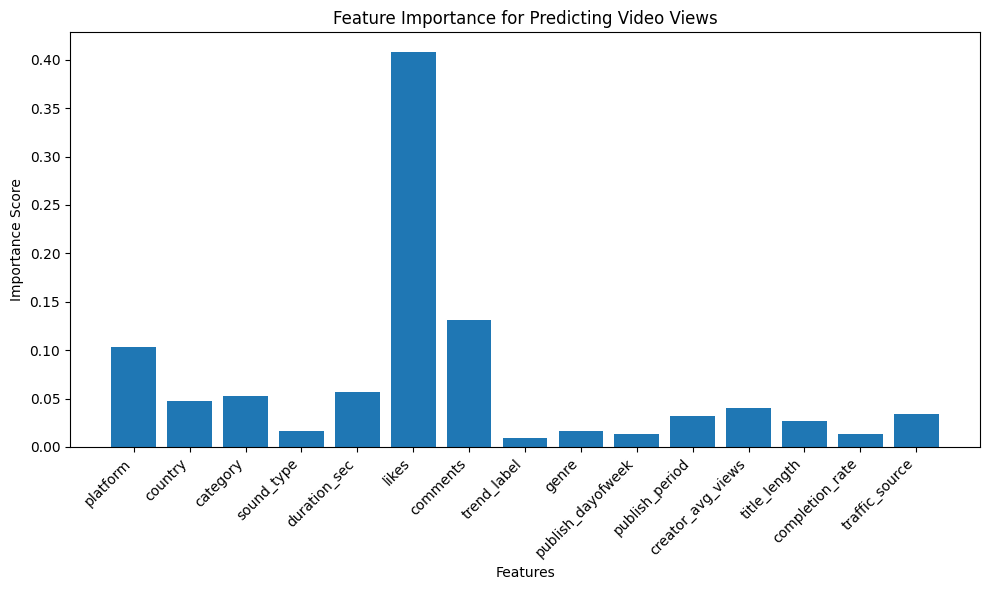

In [44]:
# Feature Importance
importances = best_model.feature_importances_
features = X_encoded.columns

# Create dataframe for easier analysis
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance_df.head(10))

plt.figure(figsize=(10,6))
plt.bar(features, importances)
plt.title("Feature Importance for Predicting Video Views")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [45]:
# Scale features for Linear Regression and K-Means
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Convert back to DataFrame to keep column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)

# K-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)



In [ ]:
# K-Means Clustering with Scaled Features
from sklearn.cluster import KMeans
#Need pandas as pd and numpy as np imported already

# Fit KMeans on scaled features
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled_df)

# X_scaled_df, kmeans, kmeans_labels, scaler, y_encoded assumed defined above
cluster_series = pd.Series(kmeans_labels, name='cluster')
df_clusters = pd.concat([X_scaled_df.reset_index(drop=True), cluster_series.reset_index(drop=True), y_encoded.reset_index(drop=True)], axis=1)

# Cluster counts and view stats
cluster_counts = df_clusters['cluster'].value_counts().sort_index()
cluster_view_stats = df_clusters.groupby('cluster')['views'].agg(['count','mean','median','std']).rename(columns={'count':'n'})

print("Cluster counts:\n", cluster_counts)
print("\nCluster view stats (# of videos in cluster, mean views, median views, std views):\n", cluster_view_stats)

# Quick note: Can't use clusters as later feature because we use cross-validation which would leak info
# Next we give train/test split to avoid leakage

Cluster counts:
 cluster
0    1076
1     919
2     988
3     918
4     963
Name: count, dtype: int64

Cluster view stats (# of videos in cluster, mean views, median views, std views):
             n           mean   median            std
cluster                                             
0        1076   95528.157993  61441.0  118405.505849
1         919   97281.602829  57240.0  127290.487916
2         988   97979.859312  59563.5  126053.218790
3         918  105387.538126  64592.5  135662.229241
4         963   96682.857736  56399.0  131114.432589


In [ ]:
# Linear Regression with CLUSTER Features compare to model without cluster features
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#To avoid cross validation problem, using train/test split

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y_encoded, test_size=0.2, random_state=42
)
#retrain KMeans on training data only
kmeans_train = KMeans(n_clusters=5, random_state=42, n_init=10)
train_clusters = kmeans_train.fit_predict(X_train)
test_clusters = kmeans_train.predict(X_test)

X_train_with_clusters = X_train.copy()
X_train_with_clusters['kmeans_cluster'] = train_clusters

X_test_with_clusters = X_test.copy()
X_test_with_clusters['kmeans_cluster'] = test_clusters

lr_model_cluster = LinearRegression()
lr_model_cluster.fit(X_train_with_clusters, y_train)
y_pred_cluster = lr_model_cluster.predict(X_test_with_clusters)
rmse_cluster = np.sqrt(mean_squared_error(y_test, y_pred_cluster))
mae_cluster = mean_absolute_error(y_test, y_pred_cluster)
r2_cluster = r2_score(y_test, y_pred_cluster)

print(f"Linear Regression (with clusters):")
print("="*50)
print(f"  Test RMSE: {rmse_cluster:,.2f}")
print(f"  Test MAE: {mae_cluster:,.2f}")
print(f"  Test R²: {r2_cluster:.4f}")
print("="*50)

In [47]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression

print("Training Linear Regression Model (with scaled features)...")

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_scaled_df, y_encoded)

# Make predictions
y_pred_lr = lr_model.predict(X_scaled_df)

# Perform cross-validation predictions
y_pred_lr_cv = cross_val_predict(lr_model, X_scaled_df, y_encoded, cv=kf)

# Calculate metrics
mse_lr = mean_squared_error(y_encoded, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_encoded, y_pred_lr)
r2_lr = r2_score(y_encoded, y_pred_lr)

# Calculate cross-validation metrics
mse_lr_cv = mean_squared_error(y_encoded, y_pred_lr_cv)
rmse_lr_cv = np.sqrt(mse_lr_cv)
mae_lr_cv = mean_absolute_error(y_encoded, y_pred_lr_cv)
r2_lr_cv = r2_score(y_encoded, y_pred_lr_cv)


print("\n" + "="*50)
print("Linear Regression Results (Scaled Features)")
print("="*50)
print(f"RMSE: {rmse_lr:,.2f}")
print(f"MAE: {mae_lr:,.2f}")
print(f"R² Score: {r2_lr:.4f}")
print("="*50)
print("Cross-Validation Results:")
print(f"CV RMSE: {rmse_lr_cv:,.2f}")
print(f"CV MAE: {mae_lr_cv:,.2f}")
print(f"CV R² Score: {r2_lr_cv:.4f}")
print("="*50)


Training Linear Regression Model (with scaled features)...

Linear Regression Results (Scaled Features)
RMSE: 55,460.47
MAE: 28,640.99
R² Score: 0.8109
Cross-Validation Results:
CV RMSE: 57,261.04
CV MAE: 28,989.76
CV R² Score: 0.7984


In [48]:
# Polynomial Regression Model 
from sklearn.preprocessing import PolynomialFeatures


p_features = PolynomialFeatures(degree=2)
X_poly = p_features.fit_transform(X_scaled_df)

# Train-test split
kf = KFold(n_splits=5, random_state=42, shuffle=True)

# Train polynomial regression model
p_model = LinearRegression()
p_model.fit(X_poly, y_encoded)

y_pred_p = p_model.predict(X_poly)

# Perform cross-validation predictions
y_pred_p_cv = cross_val_predict(p_model, X_poly, y_encoded, cv=kf)

# Calculate metrics
mse_p = mean_squared_error(y_encoded, y_pred_p)
rmse_p = np.sqrt(mse_p)
mae_p = mean_absolute_error(y_encoded, y_pred_p)
r2_p = r2_score(y_encoded, y_pred_p)
# Calculate cross-validation metrics
mse_p_cv = mean_squared_error(y_encoded, y_pred_p_cv)
rmse_p_cv = np.sqrt(mse_p_cv)
mae_p_cv = mean_absolute_error(y_encoded, y_pred_p_cv)
r2_p_cv = r2_score(y_encoded, y_pred_p_cv)
print("\n" + "="*50)
print("Polynomial Regression Results (Scaled Features)")
print("="*50)
print(f"RMSE: {rmse_p:,.2f}")
print(f"MAE: {mae_p:,.2f}")
print(f"R² Score: {r2_p:.4f}")
print("="*50)
print("Cross-Validation Results:")
print(f"CV RMSE: {rmse_p_cv:,.2f}")
print(f"CV MAE: {mae_p_cv:,.2f}")
print(f"CV R² Score: {r2_p_cv:.4f}")
print("="*50)






Polynomial Regression Results (Scaled Features)
RMSE: 42,244.11
MAE: 23,339.05
R² Score: 0.8903
Cross-Validation Results:
CV RMSE: 48,296.98
CV MAE: 25,029.17
CV R² Score: 0.8566


C:\Users\boyla\AppData\Local\Temp\ipykernel_12432\174172885.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(lims, lims, 'k--', color='grey', linewidth=1)


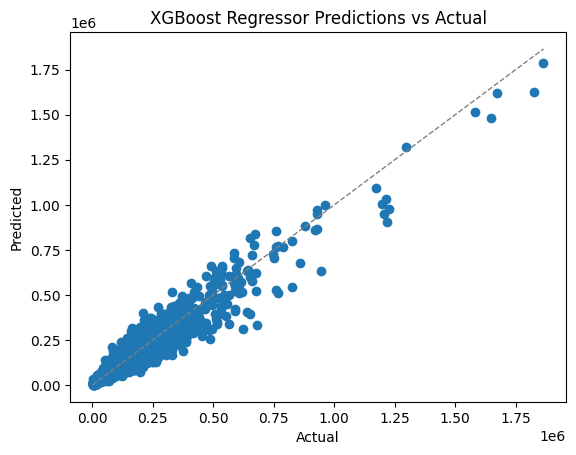

C:\Users\boyla\AppData\Local\Temp\ipykernel_12432\174172885.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(lims, lims, 'k--', color='grey', linewidth=1)


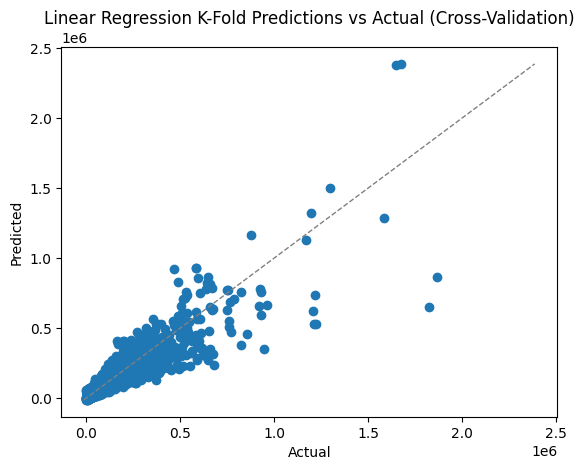

C:\Users\boyla\AppData\Local\Temp\ipykernel_12432\174172885.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(lims, lims, 'k--', color='grey', linewidth=1)


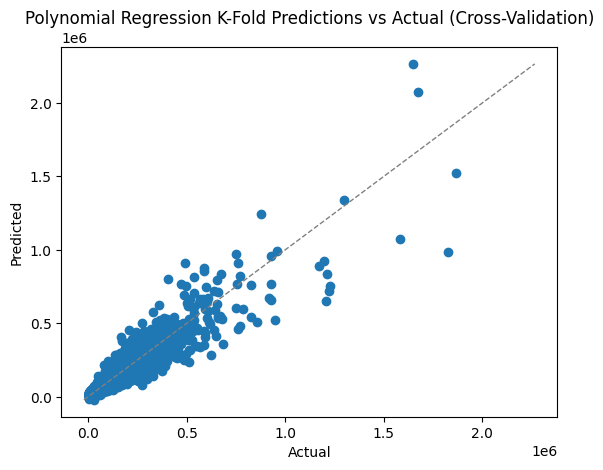

In [49]:
# Visualizing Models

# XGBoost Predictions vs Actual
plt.scatter(y_encoded, y_pred)
plt.title(f'XGBoost Regressor Predictions vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
lims = [
    np.min([y_encoded.min(), y_pred.min()]),
    np.max([y_encoded.max(), y_pred.max()])
]
# Add diagonal line
plt.plot(lims, lims, 'k--', color='grey', linewidth=1)
plt.show()

# Linear Regression Predictions vs Actual
# K-fold cross-validation visualization
plt.scatter(y_encoded, y_pred_lr_cv)
plt.title(f'Linear Regression K-Fold Predictions vs Actual (Cross-Validation)')
plt.xlabel('Actual')
plt.ylabel('Predicted')

lims = [
    np.min([y_encoded.min(), y_pred_lr_cv.min()]),
    np.max([y_encoded.max(), y_pred_lr_cv.max()])
]

# Add diagonal line
plt.plot(lims, lims, 'k--', color='grey', linewidth=1)  

plt.show()

# Polynomial Regression Predictions vs Actual
plt.scatter(y_encoded, y_pred_p_cv)
plt.title(f'Polynomial Regression K-Fold Predictions vs Actual (Cross-Validation)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
lims = [
    np.min([y_encoded.min(), y_pred_p_cv.min()]),
    np.max([y_encoded.max(), y_pred_p_cv.max()])
]
# Add diagonal line
plt.plot(lims, lims, 'k--', color='grey', linewidth=1)
plt.show()


Top 10 Most Important Features (Linear Regression)
              feature   coefficient
5               likes  1.868707e+06
6            comments  4.025540e+05
0            platform  4.231763e+04
11  creator_avg_views  4.102817e+04
13    completion_rate  6.579017e+03
2            category  6.197340e+03
10     publish_period  4.484691e+03
4        duration_sec  3.661035e+03
8               genre  2.994157e+03
14     traffic_source  1.367822e+03


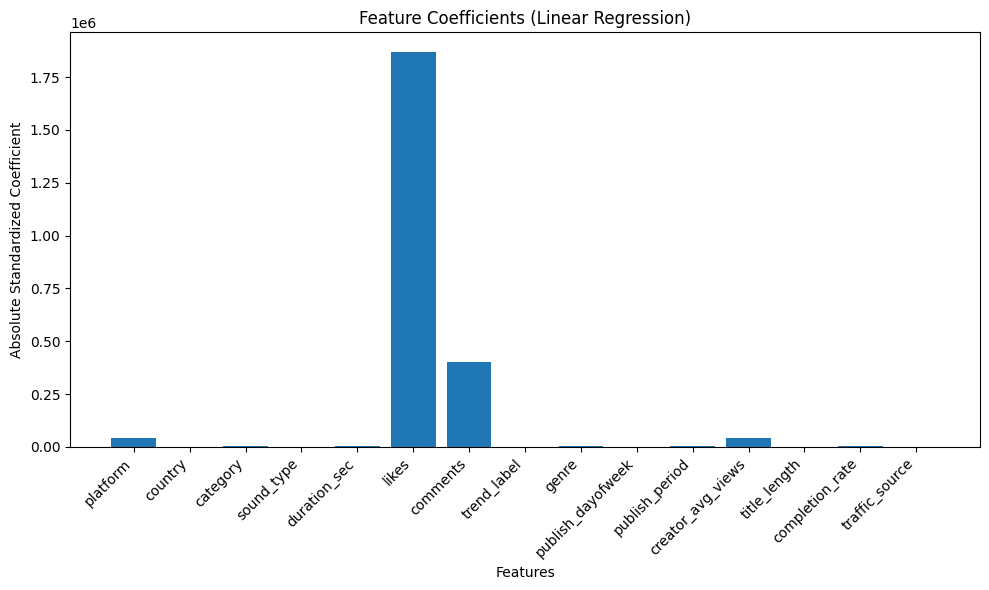

In [50]:
# Feature Importance for Linear Regression (Coefficients)

coefficients = lr_model.coef_
features_lr = X_scaled_df.columns

# Create dataframe for easier analysis
coef_importance_df = pd.DataFrame({
    'feature': features_lr,
    'coefficient': np.abs(coefficients)  # Use absolute values
}).sort_values('coefficient', ascending=False)

print("Top 10 Most Important Features (Linear Regression)")
print(coef_importance_df.head(10))

plt.figure(figsize=(10,6))
plt.bar(features_lr, np.abs(coefficients))
plt.title("Feature Coefficients (Linear Regression)")
plt.xlabel("Features")
plt.ylabel("Absolute Standardized Coefficient")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [51]:
# Model Comparison
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': ['XGBoost', 'Linear Regression (Cross-Validation)', 'Polynomial Regression (Cross-Validation)'],
    'RMSE': [rmse, rmse_lr_cv, rmse_p_cv],
    'MAE': [mae, mae_lr_cv, mae_p_cv],
    'R² Score': [r2, r2_lr_cv, r2_p_cv]
})

print("\n" + "="*100)
print("MODEL COMPARISON")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)




MODEL COMPARISON
                                   Model         RMSE          MAE  R² Score
                                 XGBoost 35401.011511 20741.607422  0.922937
    Linear Regression (Cross-Validation) 57261.040504 28989.757843  0.798381
Polynomial Regression (Cross-Validation) 48296.975270 25029.174543  0.856566
